In [19]:
import numpy as np, pandas as pd


In [20]:
port_df = pd.read_pickle('../8YearsData.pkl')
gics = pd.read_csv('sp500.csv')

In [21]:
gics = gics.set_index("Symbol")["GICS Sector"]

syms = sorted(port_df["symbol"].unique())
Xsec = pd.get_dummies(gics.reindex(syms)).astype(float)   # N x 11, 0/1

print(Xsec.sum(), gics.reindex(syms).isna().sum()) 

Communication Services    23.0
Consumer Discretionary    47.0
Consumer Staples          34.0
Energy                    21.0
Financials                76.0
Health Care               59.0
Industrials               83.0
Information Technology    73.0
Materials                 25.0
Real Estate               31.0
Utilities                 31.0
dtype: float64 23137


In [22]:
# --- 1. universe + exposures ------------------------------------
sec = gics.reindex(sorted(port_df["symbol"].unique())).dropna()
X   = pd.get_dummies(sec).astype(float)                  # N x 11


In [23]:
px   = port_df.reset_index().pivot(index='ts_event', columns='symbol', values='close')
rets = px[X.index].pct_change(fill_method=None).iloc[1:]
rets = rets.mask(rets.abs() > 0.5)                    # kill remaining bad prints
X    = X.loc[rets.columns]
print(rets.shape, X.shape)


(2078, 503) (503, 11)


In [24]:
Xv   = X.values
A    = np.linalg.pinv(Xv.T @ Xv)
F    = pd.DataFrame(rets.values @ Xv @ A, index=rets.index, columns=X.columns)


In [25]:
E    = pd.DataFrame(rets.values - F.values @ Xv.T, index=rets.index, columns=rets.columns)
spec = E.var() * 252


In [26]:
Fcov = F.cov() * 252

In [29]:
for s in ['Information Technology', 'Energy', 'Utilities']:
    d = F[s].abs().idxmax()
    names = sec[sec == s].index.intersection(rets.columns)
    print(s, d.date(), F[s].loc[d].round(3))
    print(rets.loc[d, names].abs().nlargest(3), "\n")

print(rets.notna().T.groupby(sec).sum().T.min())     # thinnest day per sector

Information Technology 2026-08-04 0.047
IT      0.241962
ZBRA    0.239057
ANET    0.137057
Name: 2026-08-04 00:00:00+00:00, dtype: float64 

Energy 2026-07-13 0.033
VLO    0.064528
PSX    0.056748
MPC    0.056560
Name: 2026-07-13 00:00:00+00:00, dtype: float64 

Utilities 2026-07-22 0.022
NRG    0.053669
CEG    0.046313
EIX    0.041731
Name: 2026-07-22 00:00:00+00:00, dtype: float64 

GICS Sector
Communication Services    18
Consumer Discretionary    44
Consumer Staples          32
Energy                    19
Financials                66
Health Care               53
Industrials               67
Information Technology    66
Materials                 19
Real Estate               30
Utilities                 29
dtype: int64


In [32]:
print(F.index.min(), F.index.max(), len(F))
print(rets.index.min(), rets.index.max(), rets.shape)

2018-05-02 00:00:00+00:00 2026-08-07 00:00:00+00:00 2078
2018-05-02 00:00:00+00:00 2026-08-07 00:00:00+00:00 (2078, 503)


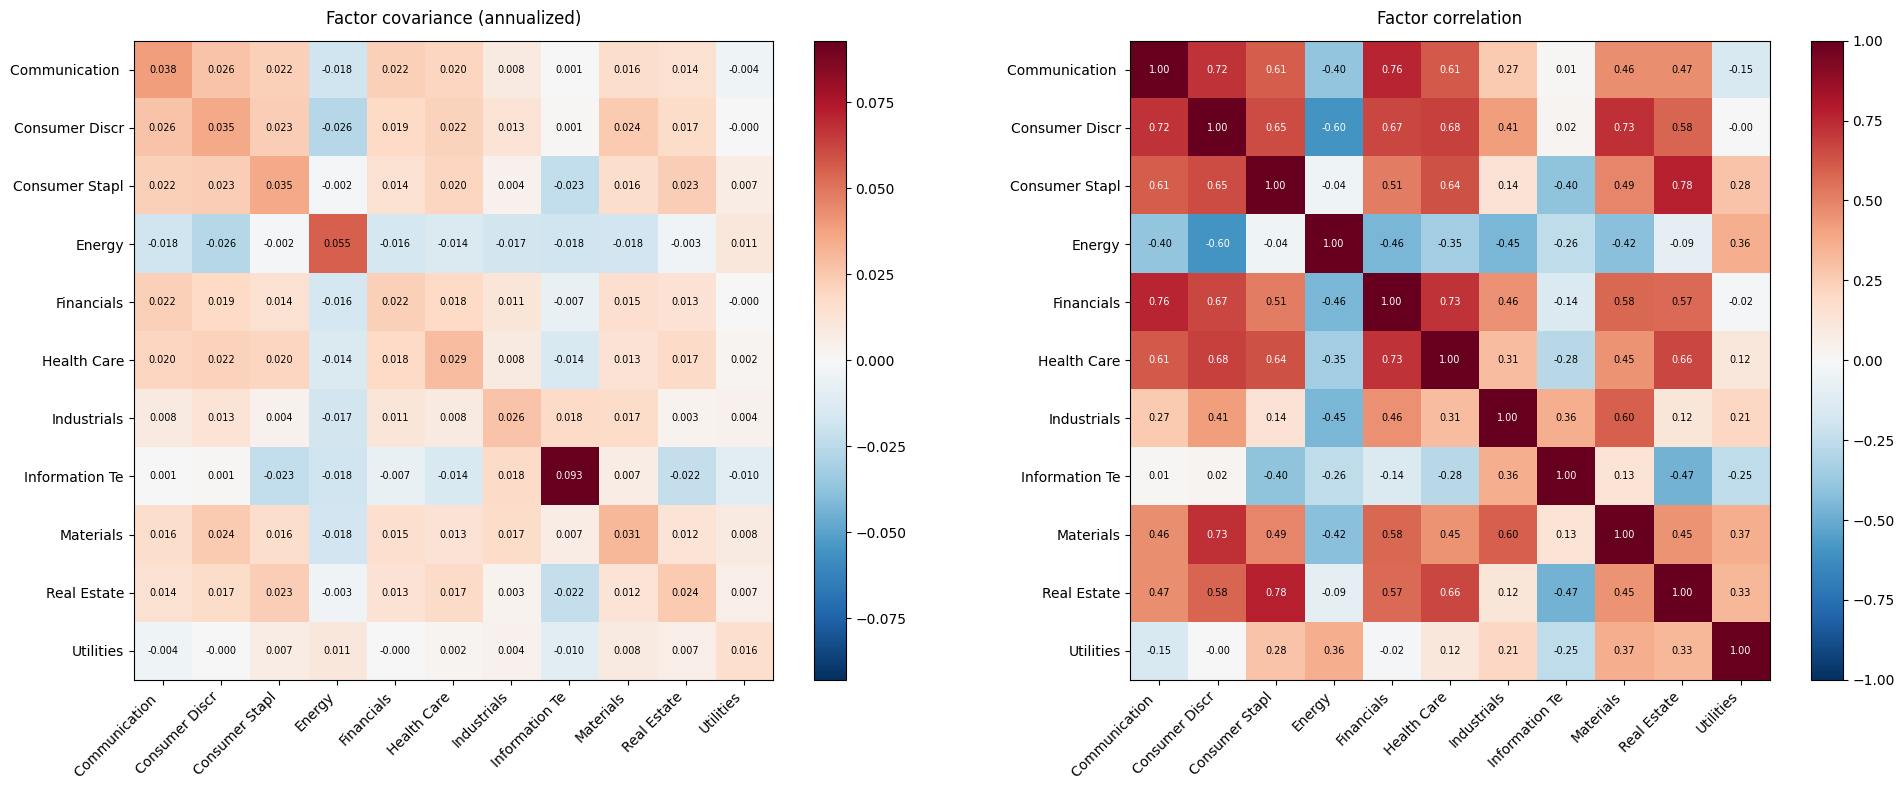

In [28]:
import matplotlib.pyplot as plt
import numpy as np

Fcorr = F.corr()
labels = [c[:14] for c in Fcov.columns]

fig, axes = plt.subplots(1, 2, figsize=(20, 8))

for ax, M, title, fmt in [
    (axes[0], Fcov,  "Factor covariance (annualized)", "{:.3f}"),
    (axes[1], Fcorr, "Factor correlation",             "{:.2f}"),
]:
    v = np.abs(M.values).max()
    im = ax.imshow(M.values, cmap="RdBu_r", vmin=-v, vmax=v)
    ax.set_xticks(range(len(M)), labels, rotation=45, ha="right")
    ax.set_yticks(range(len(M)), labels)
    ax.set_title(title, pad=12)
    fig.colorbar(im, ax=ax, fraction=0.046)
    for i in range(len(M)):
        for j in range(len(M)):
            val = M.values[i, j]
            ax.text(j, i, fmt.format(val), ha="center", va="center",
                    fontsize=7, color="white" if abs(val) > 0.6*v else "black")

plt.tight_layout()
plt.show()